In [1]:
#Import the petting zoo environment and evaluate
from Multi_Ag_Environment import CustomEnvironment
from pettingzoo.test import parallel_api_test
import gymnasium as gym
env = CustomEnvironment()
parallel_api_test(env, num_cycles=1_000_000)

Contact Plan Formatting
1
1
1
Initial Satellite Observations
{'satellite1': 30, 'satellite2': 83, 'satellite3': 87}
Initial Satellite Observations
{'satellite1': 30, 'satellite2': 83, 'satellite3': 87}
Initial Satellite Observations
{'satellite1': 30, 'satellite2': 83, 'satellite3': 87}
Contact Plan Formatting
1
1
0
Initial Satellite Observations
{'satellite1': 83, 'satellite2': 38, 'satellite3': 16}
Initial Satellite Observations
{'satellite1': 83, 'satellite2': 38, 'satellite3': 16}
Initial Satellite Observations
{'satellite1': 83, 'satellite2': 38, 'satellite3': 16}
0
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
0
Satellite successfully delivers data
{'satellite1': 9.0}
1
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
10
{'satellite1': 10, 'satellite2': 0, 'satellite3': 0}
10
2
{'satellite1': 10, 'satellite2': 10, 'satellite3': 0}
0
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 9.0}
3
4
5
6
7
8
9
10
{'satellite1': 10, 'satellite2': 10, 'satellite3'

In [2]:
#Basic Random Policy
import random
import numpy as np
# Initialize the env
env = CustomEnvironment()
num_of_episodes=10
episode_rewards=[]
# Use a fixed agent list
all_agents = ["satellite1", "satellite2", "satellite3"]
agent_rewards = {agent: [] for agent in all_agents}
# Track done flags
for episodes in range(num_of_episodes):
    obs, info = env.reset()
    
    print(obs)
    print(info)
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    total_rewards = {agent: 0 for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        for agent, r in rewards.items():
            total_rewards[agent] += r
        
        print("Rewards")
        print(rewards)
    env.close()
    for agent in all_agents:
        agent_rewards[agent].append(total_rewards.get(agent, 0))
    episode_rewards.append(np.mean(list(total_rewards.values())))

Contact Plan Formatting
1
1
0
Initial Satellite Observations
{'satellite1': 53, 'satellite2': 65, 'satellite3': 32}
Initial Satellite Observations
{'satellite1': 53, 'satellite2': 65, 'satellite3': 32}
Initial Satellite Observations
{'satellite1': 53, 'satellite2': 65, 'satellite3': 32}
{'satellite1': {'central_observation_matrix': [[0.6570441601756644, 10, 1, 1, 0], [0.1686754926866827, 10, 1, 1, 0], [0.04491416021065542, 10, 0, 1, 0], [0.8696323248713476, 10, 1, 1, 1], [0.8340741843339897, 10, 0, 1, 0], [0.8293457220350653, 10, 0, 1, 0], [0.1877008261591424, 10, 1, 1, 1], [0.5405105067825652, 10, 0, 0, 1], [0.7072413321826897, 10, 0, 0, 1], [0.12946244203119683, 10, 1, 1, 1], [0.7581669891941312, 10, 1, 1, 1], [0.6048551200268313, 10, 1, 1, 1], [0.46830337274448575, 10, 1, 0, 0], [0.12460149926706554, 10, 1, 0, 1], [0.6987796929407079, 10, 1, 0, 1], [0.4999270549046768, 10, 0, 0, 1], [-1, -1, 0, 0, 0], [-1, -1, 0, 0, 0], [-1, -1, 0, 0, 0], [-1, -1, 0, 0, 0], [-1, -1, 0, 0, 0], [-1, -

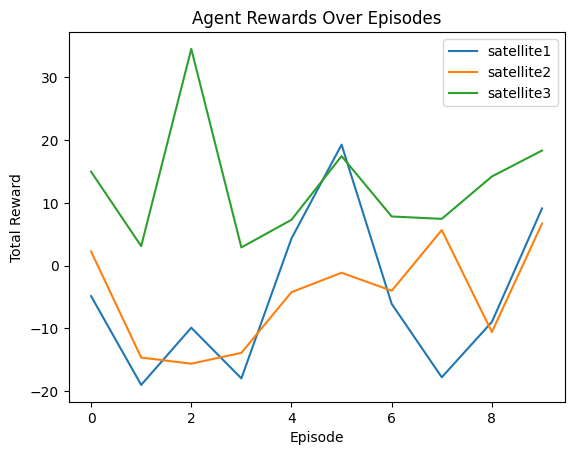

In [3]:
import matplotlib.pyplot as plt

for agent, rewards in agent_rewards.items():
    plt.plot(rewards, label=agent)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Agent Rewards Over Episodes")
plt.legend()
plt.show()

In [4]:
#Next we must display the delivery graphs along with critical performance metrics
env = CustomEnvironment()
num_of_episodes=10
episode_delivery_ratios=[]
# Use a fixed agent list
all_agents = ["satellite1", "satellite2", "satellite3"]
agent_delivery = {agent: [] for agent in all_agents}
total_delivery_ratio=None
# Track done flags
for episodes in range(num_of_episodes):
    observations,info = env.reset()
    #print(observations)
    #print("Info")
    #print(info)
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    initial_packets_to_deliver={agent: None for agent in all_agents}
    
    for a in all_agents:
        agent_info=info[a]
        initial_packets_to_deliver[a]=agent_info['satellite_initial_data_volume']
    delivered_packets = {agent: 0 for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        #print(infos)
        
        if any(terminated[a]==True or truncated[a]==True for a in all_agents):
            for agent in all_agents:
                agent_info=infos[agent]
                print(delivered_packets)
                print(agent_info['satellite_delivered_packets'])
                delivered_packets[agent] += agent_info['satellite_delivered_packets']
                print("Delivered packets for this episode")
                print(delivered_packets[agent])
    env.close()
    
    for agent in all_agents:
        agent_delivery[agent].append(delivered_packets[agent])
    #episode_delivery_ratios.append(np.mean(list(delivered_packets.values())))

Contact Plan Formatting
1
1
1
Initial Satellite Observations
{'satellite1': 84, 'satellite2': 8, 'satellite3': 84}
Initial Satellite Observations
{'satellite1': 84, 'satellite2': 8, 'satellite3': 84}
Initial Satellite Observations
{'satellite1': 84, 'satellite2': 8, 'satellite3': 84}
0
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
10
{'satellite1': 10, 'satellite2': 0, 'satellite3': 0}
10
{'satellite1': 10, 'satellite2': 10, 'satellite3': 0}
4
Satellite successfully delivers data
{'satellite1': -10, 'satellite2': -10, 'satellite3': 1.0}
1
{'satellite1': 10, 'satellite2': 10, 'satellite3': 4}
6
Satellite successfully delivers data
{'satellite1': 0.42857142857142855}
{'satellite1': 16, 'satellite2': 10, 'satellite3': 4}
5
Satellite successfully delivers data
{'satellite1': 0.42857142857142855, 'satellite2': 0, 'satellite3': 0.6666666666666666}
2
{'satellite1': 16, 'satellite2': 10, 'satellite3': 9}
4
Satellite successfully delivers data
{'satellite1': 1.0}
3
4
{'satellite1': 20, 's

{'satellite1': [39, 17, 28, 35, 41, 36, 14, 53, 28, 39], 'satellite2': [8, 42, 32, 9, 15, 39, 17, 38, 14, 33], 'satellite3': [38, 65, 38, 36, 7, 46, 40, 21, 14, 11]}


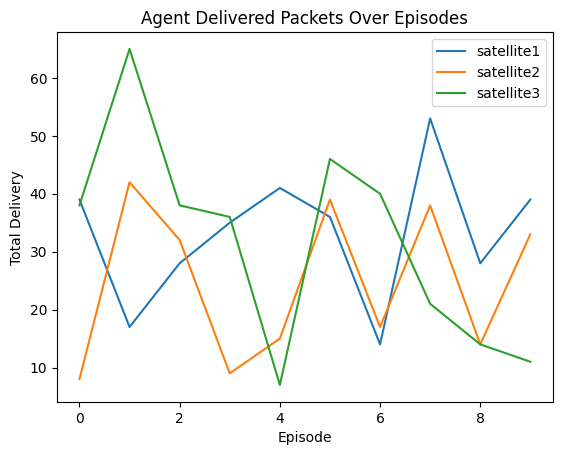

In [5]:
                      
#Next create the graph the delivery ratios
print(agent_delivery)
for agent, delivery in agent_delivery.items():
    plt.plot(delivery, label=agent)
plt.xlabel("Episode")
plt.ylabel("Total Delivery")
plt.title("Agent Delivered Packets Over Episodes")
plt.legend()
plt.show()




In [6]:
#Total delivery ratio here
env = CustomEnvironment()
num_of_episodes=10
episode_delivery_ratio=[]
# Use a fixed agent list
all_agents = ["satellite1","satellite2","satellite3"]
total_delivery=0
total_delivery_ratio=None
total_initial_data_volume=0
# Track done flags
for episodes in range(num_of_episodes):
    observations,info = env.reset()
    #print(observations)
    #print("Info")
    #print(info)
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    initial_packets_to_deliver={agent: None for agent in all_agents}
    
    for a in all_agents:
        agent_info=info[a]
        initial_packets_to_deliver[a]=agent_info['satellite_initial_data_volume']
    delivered_packets = {agent: 0 for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        
        
        if any(terminated[a]==True or truncated[a]==True for a in all_agents):
                agent_info=infos[all_agents[0]]
                total_delivery=agent_info["Delivered_Packets"]
                total_initial_data_volume=agent_info["Total_Initial_Satellite_Data_Volume"]
                
    env.close()
    print("Total Number Delivered")
    print(total_delivery)
    print("Initial Number of Packets to Deliver")
    print(total_initial_data_volume)
    episode_delivery_ratio.append(total_delivery/total_initial_data_volume)

Contact Plan Formatting
1
1
1
Initial Satellite Observations
{'satellite1': 18, 'satellite2': 74, 'satellite3': 70}
Initial Satellite Observations
{'satellite1': 18, 'satellite2': 74, 'satellite3': 70}
Initial Satellite Observations
{'satellite1': 18, 'satellite2': 74, 'satellite3': 70}
0
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
5
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0.6666666666666666}
1
2
{'satellite1': 0, 'satellite2': 0, 'satellite3': 5}
4
Satellite successfully delivers data
{'satellite1': 1.0}
{'satellite1': 4, 'satellite2': 0, 'satellite3': 5}
4
Satellite successfully delivers data
{'satellite1': 1.0, 'satellite2': 0, 'satellite3': 1.0}
3
{'satellite1': 4, 'satellite2': 0, 'satellite3': 9}
7
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0.25}
4
{'satellite1': 4, 'satellite2': 0, 'satellite3': 16}
1
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 4.0}
5
{'satel

/tmp/ipykernel_158196/3440047542.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


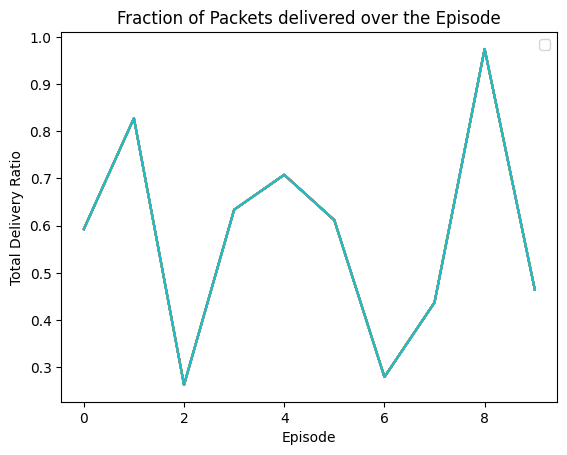

In [7]:

for episode in episode_delivery_ratio:
    plt.plot(episode_delivery_ratio)
plt.xlabel("Episode")
plt.ylabel("Total Delivery Ratio")
plt.title("Fraction of Packets delivered over the Episode")
plt.legend()
plt.show()

In [9]:
#Next we must consider the energy efficiency and expenditure graphs
env = CustomEnvironment()
num_of_episodes=10
episode_energy_expenditure=[]
# Use a fixed agent list
all_agents = ["satellite1", "satellite2", "satellite3"]
episode_total_energy_expenditure=[]
# Track done flags
for episodes in range(num_of_episodes):
    observations,info = env.reset()
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    energy_expended = {agent: None for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        if any(terminated[a]==True or truncated[a]==True for a in all_agents):
                agent_info=infos[all_agents[0]]
                total_energy_expenditure=agent_info["Total_Energy_Expended"]
                
                
    env.close()
    episode_total_energy_expenditure.append(total_energy_expenditure)

Contact Plan Formatting
1
0
1
Initial Satellite Observations
{'satellite1': 15, 'satellite2': 18, 'satellite3': 34}
Initial Satellite Observations
{'satellite1': 15, 'satellite2': 18, 'satellite3': 34}
Initial Satellite Observations
{'satellite1': 15, 'satellite2': 18, 'satellite3': 34}
0
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
6
Satellite successfully delivers data
{'satellite1': 0.42857142857142855}
1
{'satellite1': 6, 'satellite2': 0, 'satellite3': 0}
4
Satellite successfully delivers data
{'satellite1': 1.0}
2
{'satellite1': 10, 'satellite2': 0, 'satellite3': 0}
6
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 0.42857142857142855}
{'satellite1': 10, 'satellite2': 6, 'satellite3': 0}
6
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 0.42857142857142855, 'satellite3': 0.42857142857142855}
3
{'satellite1': 10, 'satellite2': 6, 'satellite3': 6}
3
Satellite successfully delivers data
{'satellite1': 1.5}
4
{'satellite1': 13, 'satelli

/tmp/ipykernel_158196/3803117114.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


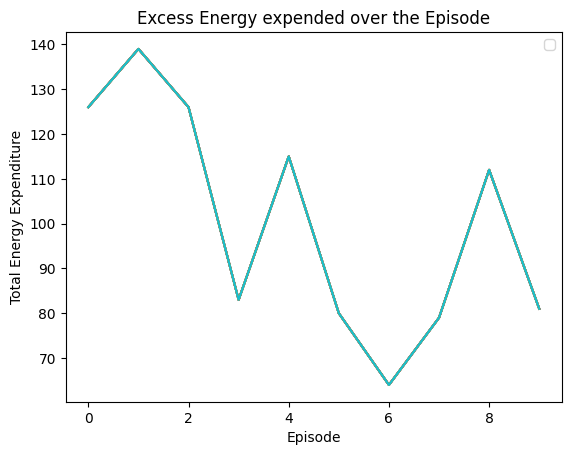

In [11]:
for episode in episode_total_energy_expenditure:
    plt.plot(episode_total_energy_expenditure)
plt.xlabel("Episode")
plt.ylabel("Total Energy Expenditure")
plt.title("Excess Energy expended over the Episode")
plt.legend()
plt.show()

In [ ]:
#Energy Expenditure per agent
env = CustomEnvironment()
num_of_episodes=10
episode_energy=[]
# Use a fixed agent list
all_agents = ["satellite1", "satellite2", "satellite3"]
agent_energy_output = {agent: [] for agent in all_agents}
agent_energy = {agent: [] for agent in all_agents}
# Track done flags
for episodes in range(num_of_episodes):
    observations,info = env.reset()
    #print(observations)
    #print("Info")
    #print(info)
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    initial_packets_to_deliver={agent: None for agent in all_agents}
    
    for a in all_agents:
        agent_info=info[a]
        initial_packets_to_deliver[a]=agent_info['satellite_initial_data_volume']
    delivered_packets = {agent: 0 for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        #print(infos)
        
        if any(terminated[a]==True or truncated[a]==True for a in all_agents):
            for agent in all_agents:
                agent_info=infos[agent]
                agent_energy[agent] = agent_info['satellite_energy_expended']
    env.close()
    print(agent_energy)
    for agent in all_agents:
        print(agent_energy[agent])
        agent_energy_output[agent].append(agent_energy[agent])

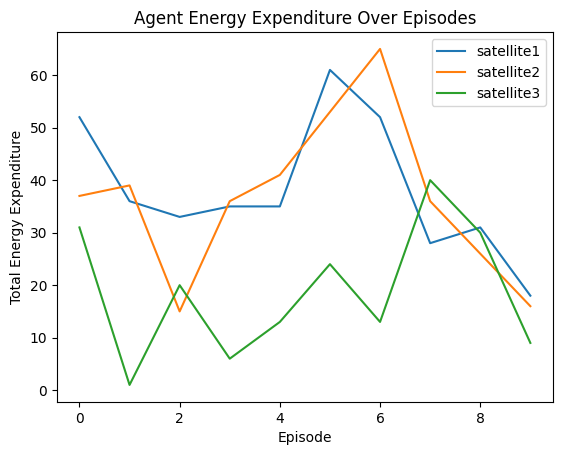

In [19]:

for agent, energy in agent_energy_output.items():
    plt.plot(energy, label=agent)
plt.xlabel("Episode")
plt.ylabel("Total Energy Expenditure")
plt.title("Agent Energy Expenditure Over Episodes")
plt.legend()
plt.show()

In [21]:
#Finally we must consider the number of collisions during an episode
env = CustomEnvironment()
num_of_episodes=10
episode_collisions=[]
# Use a fixed agent list
all_agents = ["satellite1", "satellite2", "satellite3"]
num_of_collisions=[]
# Track done flags
for episodes in range(num_of_episodes):
    observations,info = env.reset()
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    
    delivered_packets = {agent: None for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        if any(terminated[a]==True or truncated[a]==True for a in all_agents):
                agent_info=infos[all_agents[0]]
                collisions=agent_info["Number_of_Collisions"]
    env.close()
    num_of_collisions.append(collisions)

Contact Plan Formatting
1
1
0
Initial Satellite Observations
{'satellite1': 98, 'satellite2': 36, 'satellite3': 85}
Initial Satellite Observations
{'satellite1': 98, 'satellite2': 36, 'satellite3': 85}
Initial Satellite Observations
{'satellite1': 98, 'satellite2': 36, 'satellite3': 85}
0
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
0
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 9.0}
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
0
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 9.0, 'satellite3': 9.0}
1
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
5
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0.6666666666666666}
2
{'satellite1': 0, 'satellite2': 0, 'satellite3': 5}
10
{'satellite1': 10, 'satellite2': 0, 'satellite3': 5}
10
3
4
{'satellite1': 10, 'satellite2': 10, 'satellite3': 5}
7
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0.25}
5
{'sate

/tmp/ipykernel_158196/2359403451.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


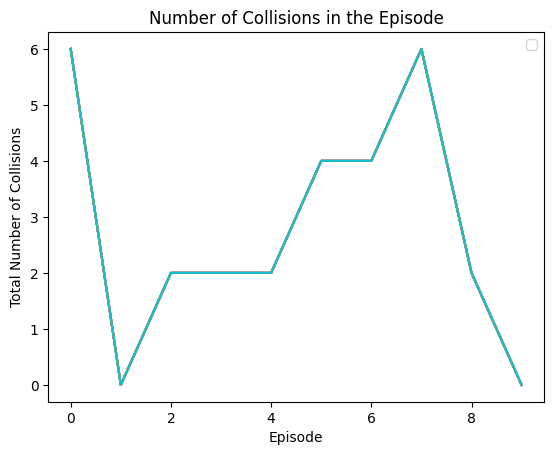

In [22]:
#Collisions Plot
for episode in num_of_collisions:
    plt.plot(num_of_collisions)
plt.xlabel("Episode")
plt.ylabel("Total Number of Collisions")
plt.title("Number of Collisions in the Episode")
plt.legend()
plt.show()

In [ ]:
#CGR
#Here we introduce CGR which will always choose Action one regardless of the weather conditions
observations = env.reset()

all_agents = ["satellite1", "satellite2", "satellite3"]

terminated = {agent: False for agent in all_agents}
truncated = {agent: False for agent in all_agents}

while not all([terminated[a] or truncated[a] for a in all_agents]):
    actions = {
        agent:1
        for agent in all_agents
        if not (terminated[agent] or truncated[agent])
    }
    print("Agent Actions")
    print(actions)
    observations, rewards, terminated, truncated, infos = env.step(actions)
    print("Rewards")
    print(rewards)




env.close()





In [31]:
#Heuristic Baseline
init_observations,init_info=env.reset()
#print("Observation info")
#print(init_observations)
#Next need to conduct necessary calculations to obtain the strategy for the actions
#With full observability we can just take satellite 1's observation space as we can see everything
#that satellite 2 and 3 can see
sat1_init_observations=init_observations["satellite1"]
contact_plan=sat1_init_observations["central_observation_matrix"]
print(contact_plan)
#Need to add order identifier to each contact
contact_count=0
for contact in contact_plan:
    contact.append(contact_count)
    contact_count+=1
#Need to manage all the satellite buffers and minimize collisions
#Dictionary that contains the remaining packets to send
satellite_buffers=sat1_init_observations["remaining_satellite_data"]
#Next need to convert this to something easily handled in the heuristic algorithm
all_agents = ["satellite1", "satellite2", "satellite3"]
satellite_buffers_algo=[]
for a in all_agents:
    satellite_buffers_algo.append(satellite_buffers[a])



#Next we need to sort the contact plan by cloud cover value
sorted_contact_plan=sorted(contact_plan,key=lambda row: row[0])
print("Sorted Matrix")
print(sorted_contact_plan)
#Next we need to allocate the contacts based upon the buffers of the satellites
estimated_capacity=0
for i in sorted_contact_plan:
    if i[0]>= 0:
        estimated_capacity=round(i[0]*10)

print("Estimated Capacity")
print(estimated_capacity)

#Now we have our initial action strategy
#We implement while loop here
actions=[]#Options are 0,1,2,3

for contact in sorted_contact_plan:
    contact_action_options=[]
    if i[0]>=0:
        for l in range(0,2):
            contact_action_options.append(i[2+l])_
        #Next we need to check how much data is left on each satellite that can transmit
        maximum_data_remaining=0
        satellite_counter=0
        max_satellite_index=None
        for sat in satellite_buffers_algo:
            
            if sat>maximum_data_remaining:
                max_satellite_index=satellite_counter
                maximum_data_remaining=sat
            satellite_counter+=1
        #Next need to check if the maximum remaining data is still 0
        if maximum_data_remaining==0:
            actions.append(0)
            #We don't want to send as no satellite that can see the ground station
            #has data to send
        else:
            #Next we will use the satellite that has the most data to send
            actions.append(max_satellite_index+1)
            #next we must update the estimated remaining data
            #Expected Number of packets sent
            
            satellite_buffers_algo[max_satellite_index]=satellite_buffers_algo[max_satellite_index]-round(contact[0]*contact[1])
            if satellite_buffers_algo[max_satellite_index]<0:
                satellite_buffers_algo[max_satellite_index=0
            
        
        
    else:
        actions.append(0)
    
        


            
#Convert actions to agent based
    

    
#Next we need to do a full update here of the action strategy



#Output metrics




#observations,info = env.reset()
#print(observations.keys()) 
##Satellite 1 observation
#satellite1_observation=observations["satellite1"]
#print(satellite1_observation)
#satellite2_observation=observations["satellite2"]
#print(satellite2_observation)

SyntaxError: incomplete input (1954683801.py, line 53)

In [ ]:
#Next we need to conduct the initial contact selection based upon the initial state
initial_contact_plan=observations.
initial_data_volume=



for i in range(number_of_contacts):
    

all_agents = ["satellite1", "satellite2", "satellite3"]


terminated = {agent: False for agent in all_agents}
truncated = {agent: False for agent in all_agents}

while not all([terminated[a] or truncated[a] for a in all_agents]):
    
    
    actions = {
        agent:
        for agent in all_agents
        if not (terminated[agent] or truncated[agent])
    }
    print("Agent Actions")
    print(actions)
    observations, rewards, terminated, truncated, infos = env.step(actions)
    print("Rewards")
    print(rewards)
env.close()

In [ ]:
import os

import ray
import supersuit as ss
from ray import tune
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.env.wrappers.pettingzoo_env import ParallelPettingZooEnv
from ray.rllib.models import ModelCatalog
from ray.rllib.models.torch.torch_modelv2 import TorchModelV2
from ray.tune.registry import register_env
from torch import nn

#from pettingzoo.butterfly import pistonball_v6


class CNNModelV2(TorchModelV2, nn.Module):
    def __init__(self, obs_space, act_space, num_outputs, *args, **kwargs):
        TorchModelV2.__init__(self, obs_space, act_space, num_outputs, *args, **kwargs)
        nn.Module.__init__(self)
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, [8, 8], stride=(4, 4)),
            nn.ReLU(),
            nn.Conv2d(32, 64, [4, 4], stride=(2, 2)),
            nn.ReLU(),
            nn.Conv2d(64, 64, [3, 3], stride=(1, 1)),
            nn.ReLU(),
            nn.Flatten(),
            (nn.Linear(3136, 512)),
            nn.ReLU(),
        )
        self.policy_fn = nn.Linear(512, num_outputs)
        self.value_fn = nn.Linear(512, 1)

    def forward(self, input_dict, state, seq_lens):
        model_out = self.model(input_dict["obs"].permute(0, 3, 1, 2))
        self._value_out = self.value_fn(model_out)
        return self.policy_fn(model_out), state

    def value_function(self):
        return self._value_out.flatten()


def env_creator(args):
    env = CustomEnvironment()
    #env = ss.color_reduction_v0(env, mode="B")
    #env = ss.dtype_v0(env, "float32")
    #env = ss.resize_v1(env, x_size=84, y_size=84)
    #env = ss.normalize_obs_v0(env, env_min=0, env_max=1)
    #env = ss.frame_stack_v1(env, 3)
    return env


if __name__ == "__main__":
    ray.init()

    env_name = "CustomEnvironment"

    register_env(env_name, lambda config: ParallelPettingZooEnv(env_creator(config)))
    ModelCatalog.register_custom_model("CNNModelV2", CNNModelV2)

    config = (
    PPOConfig()
    .environment(env=env_name, clip_actions=True)
    .env_runners(num_env_runners=4, rollout_fragment_length=128)
    .training(
        train_batch_size=512,
        lr=2e-5,
        gamma=0.99,
        lambda_=0.9,
        use_gae=True,
        clip_param=0.4,
        grad_clip=None,
        entropy_coeff=0.1,
        vf_loss_coeff=0.25,
    )
    .framework("torch")
    .debugging(log_level="ERROR")
    .resources(num_gpus=int(os.environ.get("RLLIB_NUM_GPUS", "0")))
    .update_from_dict({
        "num_sgd_iter": 10,
        "sgd_minibatch_size": 64,  # ✅ correct place
    })
)

    tune.run(
        "PPO",
        name="PPO",
        stop={"timesteps_total": 5000000 if not os.environ.get("CI") else 50000},
        checkpoint_freq=10,
        storage_path="~/ray_results/" + env_name,
        config=config.to_dict(),
    )